Name: Siddhi Shashikant Gandhi

Roll No. 33

Batch: T2

In [ ]:
!pip install transformers sentencepiece torch

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

model_name = "Helsinki-NLP/opus-mt-en-fr"

tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

print("English → French Model Loaded ✅")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

English → French Model Loaded ✅


In [ ]:
def translate(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    translated = model.generate(**inputs)
    return tokenizer.decode(translated[0], skip_special_tokens=True)

print(translate("Hello, how are you?"))
print(translate("I love artificial intelligence"))

Bonjour, comment allez-vous ?
J'aime l'intelligence artificielle


In [ ]:
model.save_pretrained("/content/en_fr_model")
tokenizer.save_pretrained("/content/en_fr_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/en_fr_model/tokenizer_config.json',
 '/content/en_fr_model/vocab.json',
 '/content/en_fr_model/source.spm',
 '/content/en_fr_model/target.spm',
 '/content/en_fr_model/added_tokens.json')

In [ ]:
import shutil
shutil.make_archive("en_fr_model", 'zip', "/content/en_fr_model")

'/content/en_fr_model.zip'

In [ ]:
from google.colab import files
files.download("en_fr_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# index.html




In [ ]:
<!DOCTYPE html>
<html>
<head>
    <title>Translator</title>
    <style>
        body {
            font-family: 'Segoe UI', sans-serif;
            background: linear-gradient(135deg, #667eea, #764ba2);
            color: white;
            text-align: center;
            padding: 50px;
        }

        .container {
            background: white;
            color: black;
            padding: 30px;
            border-radius: 15px;
            width: 50%;
            margin: auto;
            box-shadow: 0 10px 25px rgba(0,0,0,0.2);
        }

        h1 {
            margin-bottom: 20px;
        }

        textarea {
            width: 90%;
            height: 120px;
            padding: 10px;
            border-radius: 10px;
            border: 1px solid #ccc;
            font-size: 16px;
        }

        button {
            margin-top: 15px;
            padding: 12px 25px;
            border: none;
            border-radius: 25px;
            background: #667eea;
            color: white;
            font-size: 16px;
            cursor: pointer;
            transition: 0.3s;
        }

        button:hover {
            background: #5a67d8;
        }

        .output {
            margin-top: 20px;
            padding: 15px;
            background: #f7fafc;
            border-radius: 10px;
            font-size: 18px;
        }

        .label {
            font-weight: bold;
            margin-top: 10px;
        }
    </style>
</head>
<body>

    <h1>🌍 English → French Translator</h1>

    <div class="container">
        <form method="POST">
            <div class="label">Enter Text:</div>
            <textarea name="input_text" placeholder="Type something...">{{ input_text }}</textarea>
            <button type="submit">Translate</button>
        </form>

        {% if translated_text %}
            <div class="output">
                <div class="label">Translated Text:</div>
                <p>{{ translated_text }}</p>
            </div>
        {% endif %}
    </div>

</body>
</html>

# app.py

In [ ]:
from flask import Flask, render_template, request
from transformers import MarianMTModel, MarianTokenizer

# ✅ ADD THIS LINE (VERY IMPORTANT)
app = Flask(__name__)

# Load model
model = MarianMTModel.from_pretrained("en_fr_model")
tokenizer = MarianTokenizer.from_pretrained("en_fr_model")

def translate_text(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    translated = model.generate(**inputs)
    return tokenizer.decode(translated[0], skip_special_tokens=True)

@app.route("/", methods=["GET", "POST"])
def index():
    translated_text = ""

    if request.method == "POST":
        input_text = request.form["input_text"]
        translated_text = translate_text(input_text)

    return render_template("index.html",
                       translated_text=translated_text,
                       input_text=input_text if request.method == "POST" else "")

if __name__ == "__main__":
    app.run(debug=True)

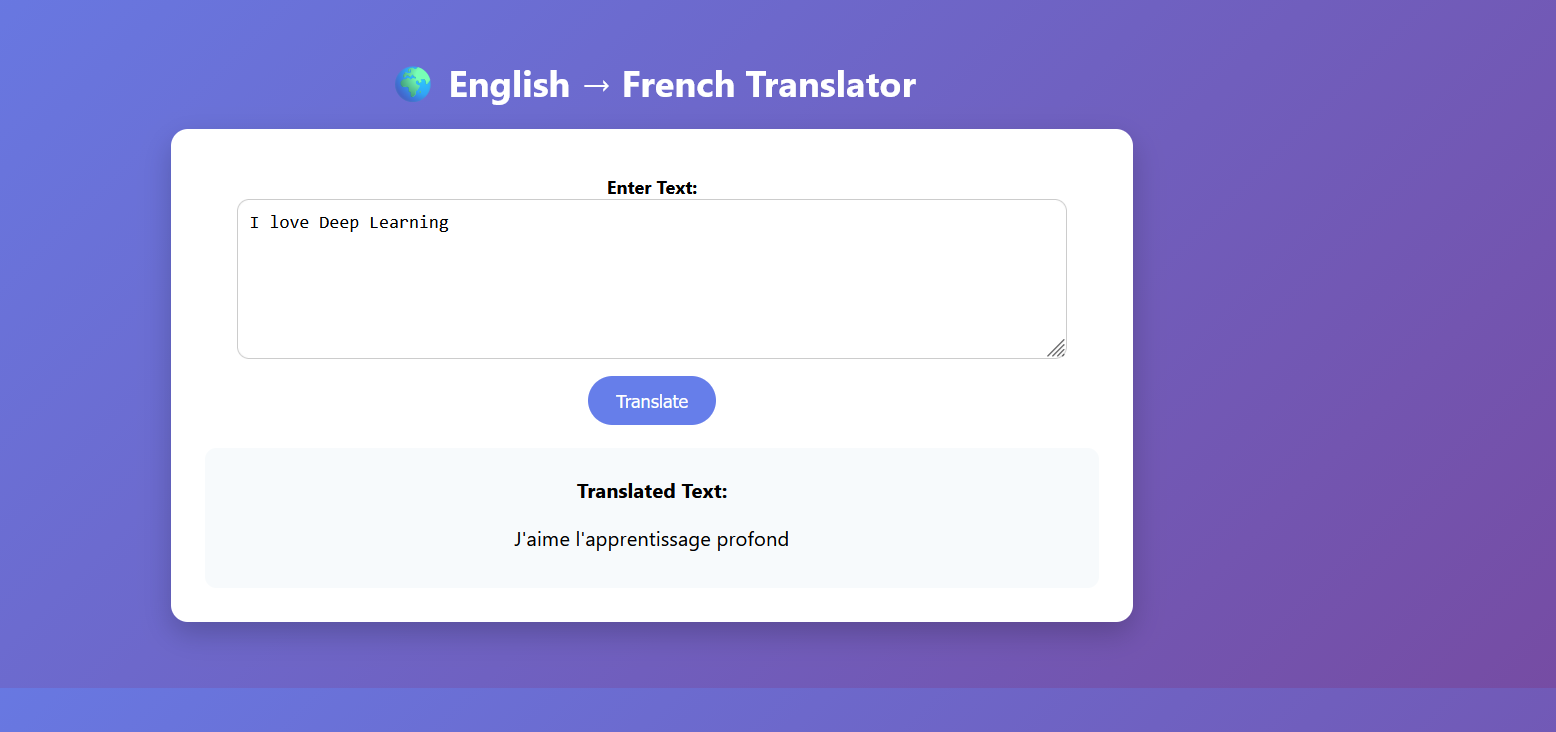